<a href="https://colab.research.google.com/github/aimeerim1/student-mental-health-classification-using-NLP/blob/googlecollabcodes/Student_Mental_Health_prediction_using_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Kütüphaneleri kur
!pip install textblob --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from textblob import TextBlob

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ Tüm kütüphaneler hazır!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Tüm kütüphaneler hazır!


In [2]:
from google.colab import files
uploaded = files.upload()  # dosyayı seç ve yükle

Saving depression-data-set-kaggle.xlsx to depression-data-set-kaggle (1).xlsx


In [3]:
df = pd.read_excel("depression-data-set-kaggle.xlsx")

print("📊 Boyut:", df.shape)
print("\n📋 Sütunlar:", df.columns.tolist())
print("\n🔍 İlk 5 satır:")
df.head()

📊 Boyut: (7489, 5)

📋 Sütunlar: ['text', 'label', 'Age', 'Gender', 'Age Category']

🔍 İlk 5 satır:


,text,label,Age,Gender,Age Category
0,let Gather For Party,0.0,16.0,Male,Teen Age
1,I hate being alive when I feel so dead inside.,1.0,17.0,Female,Teen Age
2,Exam are Comimg I m already Feeling Very Dep...,1.0,16.0,Male,Teen Age
3,Nice picture,0.0,16.0,Male,Teen Age
4,"Feeling worried, even though you actually have...",1.0,16.0,Male,Teen Age


In [4]:
# Genel bilgi
print("📊 Veri Boyutu:", df.shape)
print("\n📋 Sütun Tipleri:")
print(df.dtypes)

print("\n❓ Eksik Değerler:")
print(df.isnull().sum())

print("\n🏷️ Label Dağılımı:")
print(df['label'].value_counts())

📊 Veri Boyutu: (7489, 5)

📋 Sütun Tipleri:
text             object
label           float64
Age             float64
Gender           object
Age Category     object
dtype: object

❓ Eksik Değerler:
text            13
label            3
Age              3
Gender           3
Age Category     3
dtype: int64

🏷️ Label Dağılımı:
label
0.0    6259
1.0    1227
Name: count, dtype: int64


/tmp/ipykernel_40777/2217235242.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Blues')


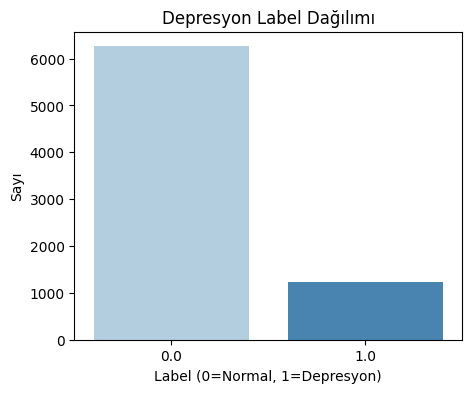

In [5]:
# Label dağılımı görseli
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df, palette='Blues')
plt.title('Depresyon Label Dağılımı')
plt.xlabel('Label (0=Normal, 1=Depresyon)')
plt.ylabel('Sayı')
plt.show()

In [6]:
# Eksik değerleri temizle
df = df.dropna(subset=['text', 'label'])
df = df.reset_index(drop=True)

print("✅ Temizleme sonrası boyut:", df.shape)

✅ Temizleme sonrası boyut: (7476, 5)


In [38]:
# Anahtar kelime listelerini genişlet
def get_severity_v3(row):
    text = str(row['text']).lower()
    label = row['label']

    severe_words = ['hopeless', 'suicide', 'die', 'kill', 'worthless',
                    'end my life', 'give up', 'no reason to live',
                    'cant go on', 'nothing matters', 'want to disappear']

    moderate_words = ['depressed', 'anxious', 'lonely', 'sad', 'crying',
                      'empty', 'tired', 'exhausted', 'miserable', 'lost',
                      'broken', 'hurt', 'pain', 'suffer', 'struggle']

    mild_words = ['stress', 'worried', 'nervous', 'upset', 'confused',
                  'unhappy', 'disappointed', 'frustrated', 'overwhelmed',
                  'exam', 'pressure', 'difficult', 'hard time']

    if label == 1.0:
        if any(w in text for w in severe_words):
            return 'Severe'
        elif any(w in text for w in moderate_words):
            return 'Moderate'
        else:
            return 'Mild'
    else:
        if any(w in text for w in mild_words):
            return 'Mild'
        else:
            return 'Minimal'

df['severity_v3'] = df.apply(get_severity_v3, axis=1)

print("🏷️ Yeni Severity Dağılımı:")
print(df['severity_v3'].value_counts())

🏷️ Yeni Severity Dağılımı:
severity_v3
Minimal     6115
Mild         932
Moderate     268
Severe       161
Name: count, dtype: int64


In [39]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Küçük harfe çevir
    text = str(text).lower()
    # Harf dışındakileri kaldır
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    words = text.split()
    # Stopwords kaldır + lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(preprocess_text)

print("✅ Preprocessing tamamlandı!")
print("\n📝 Örnek orijinal metin:")
print(df['text'][0])
print("\n📝 Temizlenmiş metin:")
print(df['clean_text'][0])

✅ Preprocessing tamamlandı!

📝 Örnek orijinal metin:
let Gather For Party

📝 Temizlenmiş metin:
let gather party


In [46]:
!pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['severity_v3']

print("📊 SMOTE öncesi dağılım:")
print(y.value_counts())

# SMOTE uygula
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\n📊 SMOTE sonrası dağılım:")
import pandas as pd
print(pd.Series(y_resampled).value_counts())

📊 SMOTE öncesi dağılım:
severity_v3
Minimal     6115
Mild         932
Moderate     268
Severe       161
Name: count, dtype: int64

📊 SMOTE sonrası dağılım:
severity_v3
Minimal     6115
Mild        6115
Moderate    6115
Severe      6115
Name: count, dtype: int64


In [47]:
# SMOTE sonrası veriyle split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print("✅ Train/Test Split tamamlandı!")
print(f"📊 Eğitim seti: {X_train.shape}")
print(f"📊 Test seti  : {X_test.shape}")

✅ Train/Test Split tamamlandı!
📊 Eğitim seti: (19568, 5000)
📊 Test seti  : (4892, 5000)


In [48]:
# Modeli oluştur ve eğit
model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model eğitimi tamamlandı!")
print(f"\n📋 Sınıflar: {model.classes_}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Model eğitimi tamamlandı!

📋 Sınıflar: ['Mild' 'Minimal' 'Moderate' 'Severe']


In [49]:
# Tahmin yap
y_pred = model.predict(X_test)

# Accuracy
print(f"🎯 Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Mild', 'Minimal', 'Moderate', 'Severe']))

🎯 Accuracy: 0.9575

📋 Classification Report:
              precision    recall  f1-score   support

        Mild       0.96      0.88      0.92      1223
     Minimal       0.89      0.95      0.92      1223
    Moderate       0.99      1.00      0.99      1223
      Severe       1.00      1.00      1.00      1223

    accuracy                           0.96      4892
   macro avg       0.96      0.96      0.96      4892
weighted avg       0.96      0.96      0.96      4892



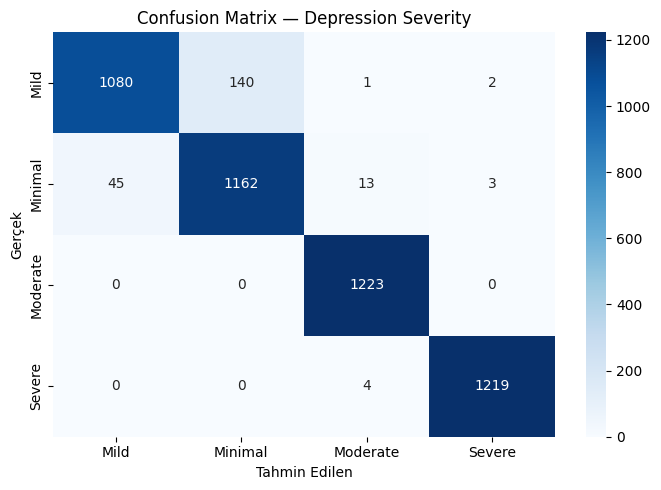

In [51]:
# Confusion Matrix görseli
plt.figure(figsize=(7,5))
cm = confusion_matrix(y_test, y_pred,
                      labels=['Mild','Minimal','Moderate','Severe'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mild','Minimal','Moderate','Severe'],
            yticklabels=['Mild','Minimal','Moderate','Severe'])
plt.title('Confusion Matrix — Depression Severity')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.show()

In [56]:
test_metinler = [
    "I want to end my life, there is no point anymore",
    "I am feeling a bit stressed about my homework",
    "Today was amazing, I feel so happy and energetic!",
    "I cry every night, I feel so empty and broken",
    "I failed my exam and I am worried about my grades",
    "I am so tired I hate exams , life is terrible"
]

print("=" * 55)
for metin in test_metinler:
    predict_severity(metin)
    print("─" * 55)

📝 Metin     : I want to end my life, there is no point anymore
🎯 Tahmin    : Severe

📊 Olasılıklar:
   Mild      : 0.2239
   Minimal   : 0.0106
   Moderate  : 0.0261
   Severe    : 0.7394
───────────────────────────────────────────────────────
📝 Metin     : I am feeling a bit stressed about my homework
🎯 Tahmin    : Mild

📊 Olasılıklar:
   Mild      : 0.9248
   Minimal   : 0.0390
   Moderate  : 0.0197
   Severe    : 0.0165
───────────────────────────────────────────────────────
📝 Metin     : Today was amazing, I feel so happy and energetic!
🎯 Tahmin    : Minimal

📊 Olasılıklar:
   Mild      : 0.3767
   Minimal   : 0.5217
   Moderate  : 0.0685
   Severe    : 0.0332
───────────────────────────────────────────────────────
📝 Metin     : I cry every night, I feel so empty and broken
🎯 Tahmin    : Moderate

📊 Olasılıklar:
   Mild      : 0.0622
   Minimal   : 0.0620
   Moderate  : 0.8594
   Severe    : 0.0163
───────────────────────────────────────────────────────
📝 Metin     : I failed my ex